# Independent Single-band GP Baseline

In [2]:
%load_ext autoreload
%autoreload 2
from datasets import load_dataset
from GP_model import fit_basic_gp
from visualization import plot_gp_fit
from data_processing import process_one_obj_one_band

dset_plasticc = load_dataset("MultimodalUniverse/plasticc",
                       streaming=True,
                       split='train')
dset_plasticc = dset_plasticc.with_format("numpy")

/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


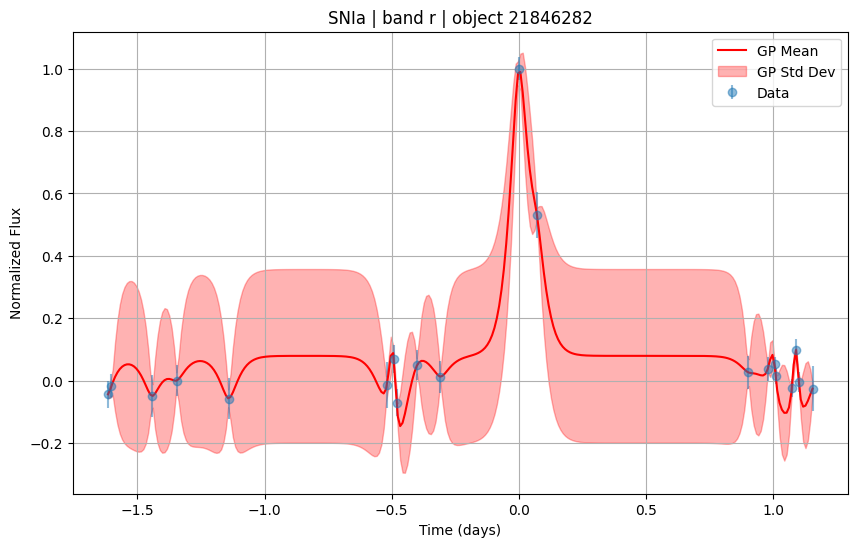

In [3]:
example = next(iter(dset_plasticc))

data = process_one_obj_one_band(example, target_band='r')
if data is not None:
    gp = fit_basic_gp(data, kernel_type="matern")
    plot_gp_fit(gp, data)

## Multi-objects on one band

Unconstrained Matern:kernel = ConstantKernel(1.0) * Matern(length_scale=0.3, nu=1.5)
And higher noise:0.3

In [8]:
import numpy as np

prepared_objects = []

dset_iterator = iter(dset_plasticc)

for i, example in zip(range(500), dset_iterator):
    data = process_one_obj_one_band(
        example,
        target_band="r",
        align_peak=True,
        normalize_flux=True,
        min_points=8,
    )

    if data is not None:
        prepared_objects.append(data)
        print(np.min(data["yerr"]), np.median(data["yerr"]), np.max(data["yerr"]))

print("number of usable objects:", len(prepared_objects))

0.023923717 0.044506773 0.07394759
0.050455526 0.08186242 0.1243165
0.09897589 0.15759754 0.25484547
0.00036992045 0.0006143678 0.005009557
0.02172172 0.047246072 0.07114961
0.03311875 0.06707094 0.11008544
0.010196236 0.022302518 0.04054288
0.032263555 0.06865703 0.10954704
0.034623444 0.10556647 0.16789038
0.033959974 0.06508212 0.11091445
0.026309019 0.05469425 0.10455511
0.039679497 0.06941345 0.117931455
0.0036056964 0.00885603 0.015104389
0.0014955392 0.00448307 0.008963429
0.015701331 0.03085626 0.056639303
0.010919944 0.018603384 0.03727177
0.008556754 0.020484606 0.034463428
0.029406933 0.046728224 0.0890774
0.048371464 0.09180884 0.19809304
0.079814166 0.14818762 0.2264985
0.019528441 0.031279325 0.06783643
0.037351232 0.057684824 0.10662571
0.05415431 0.09277719 0.1547873
0.5313289 0.69672406 1.5314168
0.01587348 0.021993928 0.053439878
0.07077617 0.092653766 0.20290491
0.20072089 0.3292376 0.71703434
0.04184459 0.06628788 0.09637488
0.017610611 0.028007723 0.04016513
0.0322

In [17]:
from GP_model import extract_basic_gp_features

features = []
labels = []

for data in prepared_objects:   # Iterate over each prepared object
    gp = fit_basic_gp(data, kernel_type="matern")
    feat = extract_basic_gp_features(gp, data)
    features.append([feat['peak_flux'], feat['peak_time'], feat['decay_slope'], feat['mean_uncertainty']])
    labels.append(data['obj_type'])

X_features = np.array(features)
y_labels = np.array(labels)

print(X_features.shape)
print(y_labels.shape)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  w

(500, 4)
(500,)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [11]:
for idx, data in enumerate(prepared_objects[:20]):
    gp = fit_basic_gp(data)
    print(idx, data["obj_id"], data["obj_type"], gp.kernel_)

0 21846282 SNIa 1.14**2 * Matern(length_scale=0.0423, nu=1.5)
1 114421739 AGN 1.03**2 * Matern(length_scale=0.301, nu=1.5)
2 30652072 SNII 0.946**2 * Matern(length_scale=0.0472, nu=1.5)
3 107732897 TDE 0.777**2 * Matern(length_scale=0.103, nu=1.5)
4 121186562 AGN 1.05**2 * Matern(length_scale=0.0393, nu=1.5)
5 10905347 SNII 1.07**2 * Matern(length_scale=0.0293, nu=1.5)
6 16775731 SNIa 0.801**2 * Matern(length_scale=0.046, nu=1.5)
7 31971611 SNII 1.01**2 * Matern(length_scale=0.0746, nu=1.5)
8 50875482 SNIbc 1.09**2 * Matern(length_scale=0.0341, nu=1.5)
9 52437992 AGN 1.07**2 * Matern(length_scale=0.0823, nu=1.5)
10 100164081 SLSN-I 1.23**2 * Matern(length_scale=0.0389, nu=1.5)
11 6777396 AGN 0.948**2 * Matern(length_scale=0.0242, nu=1.5)
12 56002762 SNII 0.887**2 * Matern(length_scale=0.207, nu=1.5)
13 93866109 SNIbc 1.11**2 * Matern(length_scale=0.137, nu=1.5)
14 31725628 SNII 1.11**2 * Matern(length_scale=0.0427, nu=1.5)
15 41660164 SNIbc 1.19**2 * Matern(length_scale=0.0681, nu=1.5)

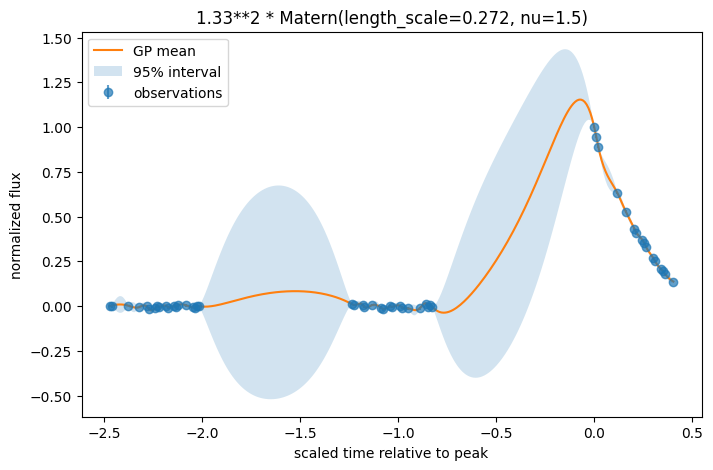

In [9]:
import matplotlib.pyplot as plt
def plot_gp_diagnostic(gp, data, n_grid=300):
    t = data["t"]
    y = data["y"]
    yerr = data["yerr"]

    t_grid = np.linspace(t.min(), t.max(), n_grid)
    X_grid = t_grid.reshape(-1, 1)

    mean, std = gp.predict(X_grid, return_std=True)

    plt.figure(figsize=(8, 5))
    plt.errorbar(t, y, yerr=yerr, fmt="o", alpha=0.7, label="observations")
    plt.plot(t_grid, mean, label="GP mean")
    plt.fill_between(t_grid, mean - 2*std, mean + 2*std, alpha=0.2, label="95% interval")
    plt.xlabel("scaled time relative to peak")
    plt.ylabel("normalized flux")
    plt.title(str(gp.kernel_))
    plt.legend()
    plt.show()
plot_gp_diagnostic(gp, data)

/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  w

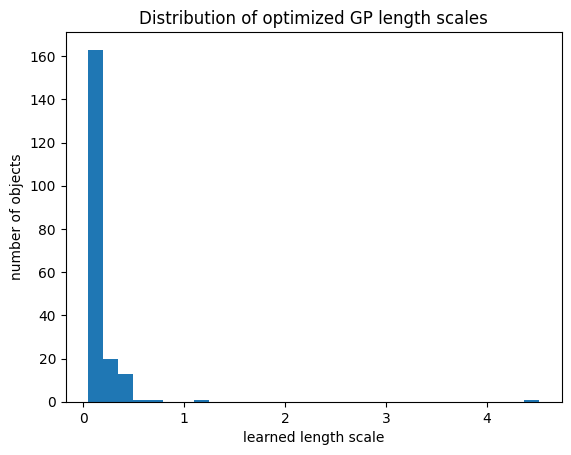

In [18]:
ells = []

for data in prepared_objects[:200]:
    gp = fit_basic_gp(data)

    params = gp.kernel_.get_params()

    if "k2__length_scale" in params:
        ell = params["k2__length_scale"]
        ells.append(ell)
    else:
        print("Could not find length scale for kernel:", gp.kernel_)

plt.hist(ells, bins=30)
plt.xlabel("learned length scale")
plt.ylabel("number of objects")
plt.title("Distribution of optimized GP length scales")
plt.show()

In [20]:
print("median ell:", np.median(ells))
print("min ell:", np.min(ells))
print("max ell:", np.max(ells))
print("fraction near lower bound:", np.mean(np.array(ells) <= 0.051))

median ell: 0.0638863908216447
min ell: 0.05000000000000001
max ell: 4.516997073610352
fraction near lower bound: 0.455


### Constrained Matern:

In [13]:
features = []
labels = []

for data in prepared_objects:   # Iterate over each prepared object
    gp = fit_basic_gp(data, kernel_type="matern")
    feat = extract_basic_gp_features(gp, data)
    features.append([feat['peak_flux'], feat['peak_time'], feat['decay_slope'], feat['mean_uncertainty']])
    labels.append(data['obj_type'])

X_features = np.array(features)
y_labels = np.array(labels)

print(X_features.shape)
print(y_labels.shape)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  w

(500, 4)
(500,)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [19]:
for idx, data in enumerate(prepared_objects[:20]):
    gp = fit_basic_gp(data)
    print(idx, data["obj_id"], data["obj_type"], gp.kernel_)

/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


0 21846282 SNIa 1.2**2 * Matern(length_scale=0.05, nu=1.5)
1 114421739 AGN 1.03**2 * Matern(length_scale=0.321, nu=1.5)
2 30652072 SNII 0.951**2 * Matern(length_scale=0.05, nu=1.5)
3 107732897 TDE 0.772**2 * Matern(length_scale=0.0999, nu=1.5)
4 121186562 AGN 1.14**2 * Matern(length_scale=0.05, nu=1.5)
5 10905347 SNII 1.13**2 * Matern(length_scale=0.05, nu=1.5)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  w

6 16775731 SNIa 0.828**2 * Matern(length_scale=0.05, nu=1.5)
7 31971611 SNII 1.01**2 * Matern(length_scale=0.0751, nu=1.5)
8 50875482 SNIbc 1.23**2 * Matern(length_scale=0.05, nu=1.5)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


9 52437992 AGN 1.08**2 * Matern(length_scale=0.0864, nu=1.5)
10 100164081 SLSN-I 1.34**2 * Matern(length_scale=0.05, nu=1.5)
11 6777396 AGN 1.13**2 * Matern(length_scale=0.05, nu=1.5)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


12 56002762 SNII 0.888**2 * Matern(length_scale=0.209, nu=1.5)
13 93866109 SNIbc 1.08**2 * Matern(length_scale=0.136, nu=1.5)
14 31725628 SNII 1.11**2 * Matern(length_scale=0.288, nu=1.5)
15 41660164 SNIbc 1.2**2 * Matern(length_scale=0.0781, nu=1.5)
16 43441391 TDE 1.14**2 * Matern(length_scale=0.105, nu=1.5)
17 46741316 SNIa 1.39**2 * Matern(length_scale=0.05, nu=1.5)
18 56383332 SNIax 0.893**2 * Matern(length_scale=0.0727, nu=1.5)
19 26794348 SNII 1.39**2 * Matern(length_scale=0.05, nu=1.5)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  w

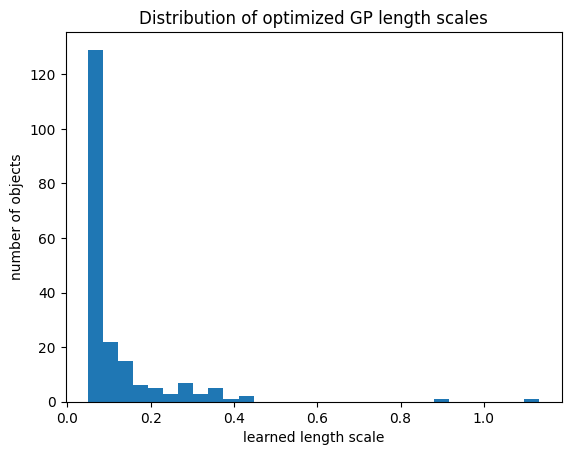

In [15]:
ells = []

for data in prepared_objects[:200]:
    gp = fit_basic_gp(data)

    params = gp.kernel_.get_params()

    if "k2__length_scale" in params:
        ell = params["k2__length_scale"]
        ells.append(ell)
    else:
        print("Could not find length scale for kernel:", gp.kernel_)

plt.hist(ells, bins=30)
plt.xlabel("learned length scale")
plt.ylabel("number of objects")
plt.title("Distribution of optimized GP length scales")
plt.show()

constrained Matérn optimization still tends to choose very short length scales as well

## Fixed length scale experiment

ell = 0.1
kernel after fit: 1**2 * Matern(length_scale=0.1, nu=1.5)


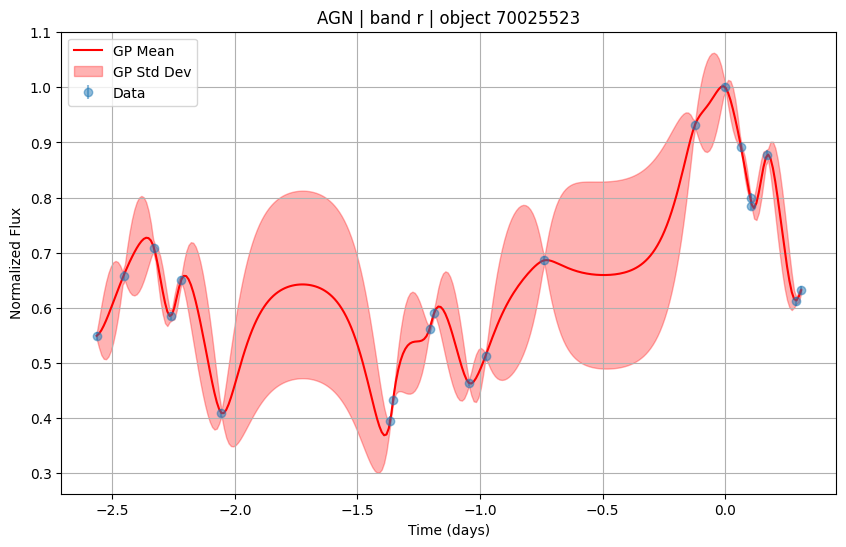

ell = 0.3
kernel after fit: 1**2 * Matern(length_scale=0.3, nu=1.5)


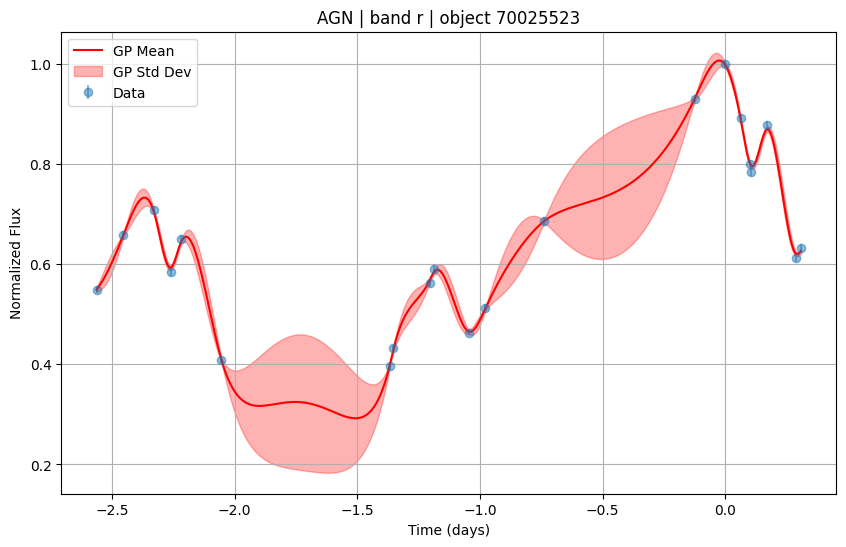

ell = 0.5
kernel after fit: 1**2 * Matern(length_scale=0.5, nu=1.5)


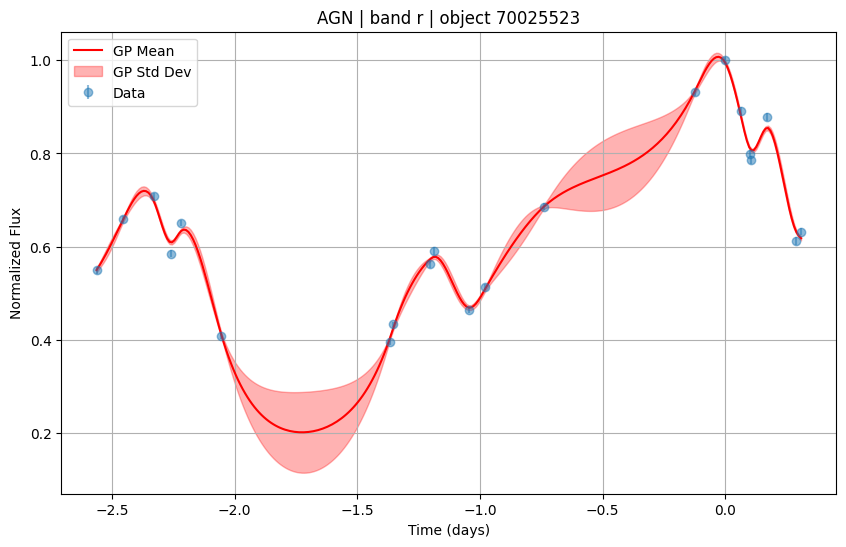

ell = 1.0
kernel after fit: 1**2 * Matern(length_scale=1, nu=1.5)


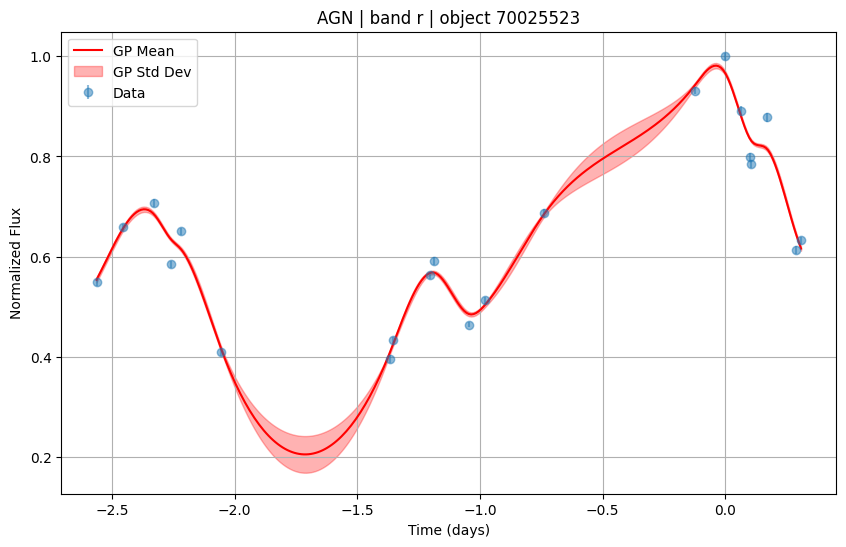

In [13]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern
# Find the optimal length scale for the Matern kernel across the first 200 objects
data = prepared_objects[101]
for ell in [0.1, 0.3, 0.5, 1.0]:
    kernel = ConstantKernel(1.0) * Matern(length_scale=ell, nu=1.5)

    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=data["yerr"]**2 + 0.03**2 + 1e-6,
        normalize_y=True,
        optimizer=None,
    )

    gp.fit(data["X"], data["y"])
    print("ell =", ell)
    print("kernel after fit:", gp.kernel_)

    plot_gp_fit(gp, data)